In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Exercise 7-1
- convert a covariance matrix into a correlation matrix
- involves dividing each matrix element (i.e. each covariance between each pair of variables) by the product of the variance of those two variables
- Done by pre- and postmulitplying the covariance matrix by a diagonal matrix containing inverted standard deviations of each variable (std dev is sqrt(var)).
- The standard deviation is inverted because we need to divide by the variances although we will multiply the matrices
- We can do this because of a special property of pre and post multiplying diagonal matrices (exercise 5-11)

$$
R = SCS
$$

In [2]:
data_points = 5
data = np.random.default_rng().random((data_points, data_points))
data

array([[0.73602739, 0.614435  , 0.34219706, 0.04881654, 0.57077441],
       [0.56517583, 0.65157641, 0.64930055, 0.18185844, 0.53258112],
       [0.78648855, 0.68950733, 0.77899209, 0.43063238, 0.76476646],
       [0.31676207, 0.9879871 , 0.83165735, 0.29197276, 0.27928921],
       [0.07942755, 0.92990895, 0.22904381, 0.44342129, 0.08546884]])

In [3]:
# mean center the data
data_mean_centered = data - np.mean(data, axis=0)
# find the covariance by premultiplying the transpose and normalizing by the count
data_cov = data_mean_centered.T @ data_mean_centered
data_cov /= (data_mean_centered.shape[0] - 1)
data_cov

array([[ 0.08810947, -0.04365438,  0.02666629, -0.02218566,  0.07715065],
       [-0.04365438,  0.02942082,  0.00295721,  0.01605485, -0.03733215],
       [ 0.02666629,  0.00295721,  0.07162635,  0.00594086,  0.03109417],
       [-0.02218566,  0.01605485,  0.00594086,  0.02815384, -0.01255975],
       [ 0.07715065, -0.03733215,  0.03109417, -0.01255975,  0.07061264]])

In [4]:
# std dev is the square root of the variance
std_dev = np.sqrt(np.diag(data_cov))
# we need the inverse square root
S = np.diag(1/std_dev)

In [5]:
# do the pre and post multiply
obs_corr = S @ data_cov @ S
obs_corr
# observe the diagonals of being 1 which makes sense. A variable is correlated with itself

array([[ 1.        , -0.85741112,  0.3356719 , -0.44544302,  0.97810867],
       [-0.85741112,  1.        ,  0.06441965,  0.55784057, -0.81905745],
       [ 0.3356719 ,  0.06441965,  1.        ,  0.13229509,  0.43722135],
       [-0.44544302,  0.55784057,  0.13229509,  1.        , -0.28168963],
       [ 0.97810867, -0.81905745,  0.43722135, -0.28168963,  1.        ]])

# Exercise 7-2
- Use the numpy built in to see if there is a difference

In [6]:
numpy_corr = np.corrcoef(data)
numpy_corr

array([[ 1.        ,  0.74975507,  0.80326238,  0.1249322 , -0.10028457],
       [ 0.74975507,  1.        ,  0.89699656,  0.63196223,  0.04940133],
       [ 0.80326238,  0.89699656,  1.        ,  0.23954003, -0.38137165],
       [ 0.1249322 ,  0.63196223,  0.23954003,  1.        ,  0.68386047],
       [-0.10028457,  0.04940133, -0.38137165,  0.68386047,  1.        ]])

In [7]:
obs_corr - numpy_corr
# observe a very small different that can be attributed to rounding errors

array([[-2.22044605e-16, -1.60716618e+00, -4.67590481e-01,
        -5.70375217e-01,  1.07839324e+00],
       [-1.60716618e+00, -2.22044605e-16, -8.32576911e-01,
        -7.41216543e-02, -8.68458786e-01],
       [-4.67590481e-01, -8.32576911e-01,  2.22044605e-16,
        -1.07244938e-01,  8.18592997e-01],
       [-5.70375217e-01, -7.41216543e-02, -1.07244938e-01,
         2.22044605e-16, -9.65550097e-01],
       [ 1.07839324e+00, -8.68458786e-01,  8.18592997e-01,
        -9.65550097e-01,  0.00000000e+00]])

# Exercise 7-3

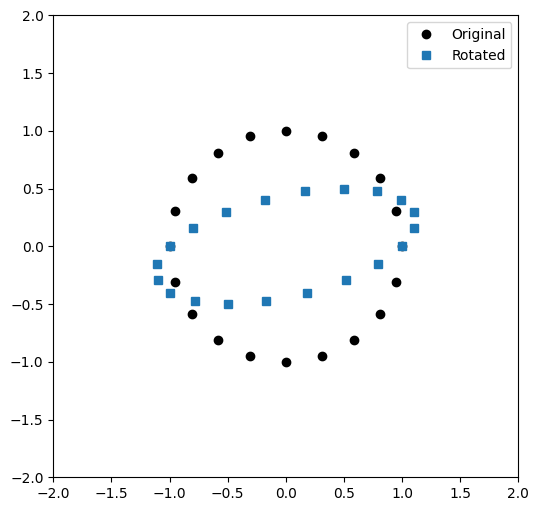

In [8]:
theta = np.linspace(0,2*np.pi-2*np.pi/20,20)
points = np.vstack((np.sin(theta),np.cos(theta)))
rot_matrix = np.array([[1, 0.5],[0, 0.5]])
rot_points = rot_matrix @ points

plt.figure(figsize=(6,6))
plt.plot(points[0], points[1], "ko", label="Original")
plt.plot(rot_points[0], rot_points[1], "s", label="Rotated")
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.legend()

What we are seeing here is how a matrix can store the rotation of the points

# Exercise 7-4
- Coiling DNA animation

$$
T = \begin{bmatrix}(1- \phi / 3) & 0 \\ 0 & \phi \end{bmatrix}
$$

In [14]:
# function to draw the plots
def aframe(ph, y1, y2, plt1, plt2):

  # create the transformation matrix
  T = np.array([ [  1-ph/3,0 ],
                 [  0,ph   ] ])

  # apply the transformation to the points using matrix multiplication
  P1 = T@y1
  P2 = T@y2

  # update the lower/upper lines
  plt1.set_xdata(P1[0,:])
  plt1.set_ydata(P1[1,:])

  plt2.set_xdata(P2[0,:])
  plt2.set_ydata(P2[1,:])

  # export the plot handles
  return (plt1,plt2)

Error in callback <function _draw_all_if_interactive at 0x10a694b80> (for post_execute), with arguments args (),kwargs {}:


TypeError: aframe() takes 5 positional arguments but 6 were given

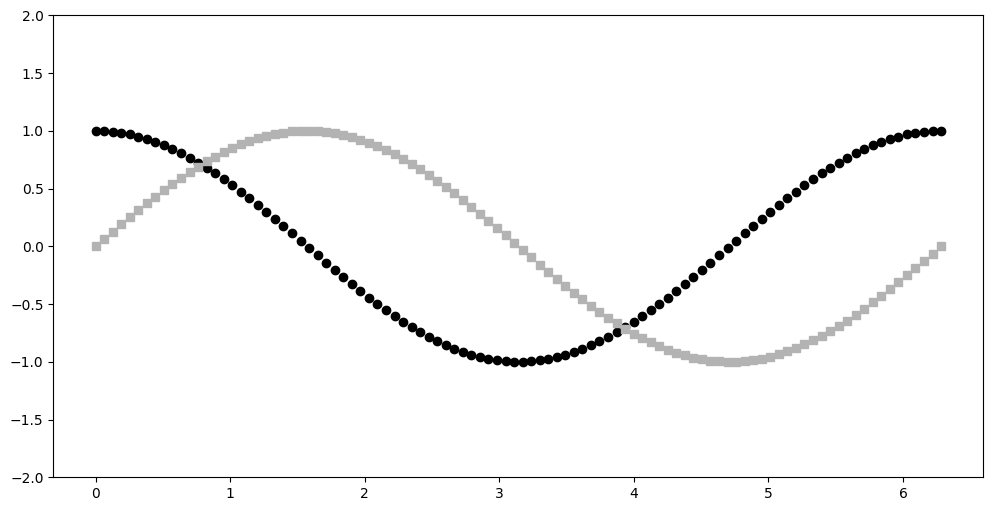

In [16]:
# define XY points
th = np.linspace(0,2*np.pi,100) # th = theta (angles)
Y1 = np.vstack((th,np.cos(th)))
Y2 = np.vstack((th,np.sin(th)))


# setup figure
fig,ax = plt.subplots(1,figsize=(12,6))

plth1, = ax.plot(Y1[0,:],Y1[1,:],'ko')
plth2, = ax.plot(Y2[0,:],Y2[1,:],'s',color=[.7,.7,.7])
ax.set_ylim([-2,2])


# define phases and run animation
phi = 1-np.linspace(-1,1-1/40,40)**2
animation.FuncAnimation(fig, aframe,phi, fargs=(phi, Y1, Y2,plth1,plth2), interval=50, repeat=True)

Could not get this to work even though it was basically copy pasted from book code.